# Movie Sentiment Aggregation

This notebook aggregates sentence-level sentiment scores up to the movie level for the dashboard.

In [3]:
import pandas as pd
import os

# Configure paths
# Google Colab Drive Mount & Checkpoint Configuration
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE_DIR = '/content/drive/MyDrive/Projects/letterboxd'
    print("Running in Google Colab. Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Using local directory for checkpoints.")
    DRIVE_BASE_DIR = './absa_project'

file_path = os.path.join(DRIVE_BASE_DIR, 'letterboxd_sentences_with_sentiment.parquet')

try:
    df = pd.read_parquet(file_path)
    print(f"Loaded {len(df)} sentiment records.")
except Exception as e:
    print(e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Google Colab. Drive mounted successfully.
Loaded 399909 sentiment records.


In [4]:
# Aggregate by film_id and film_name to match dashboard expectations
movie_summary = df.groupby(['film_id', 'film_name']).agg(
    total_reviews=('review_id', 'nunique'),
    total_sentences=('sentence_id', 'count'),
    avg_predicted_sentiment=('sentiment_numeric', 'mean'),
    avg_original_rating=('star_rating_num', 'mean'),
    genres=('genres', 'first')
).reset_index()

# Sort by review count to see most popular movies
movie_summary = movie_summary.sort_values(by='total_reviews', ascending=False)
movie_summary.head(10)

,film_id,film_name,avg_sentiment,sentiment_std,review_count,sentence_count
978,979,Doctor Sleep,3.436533,1.389232,100,323
462,463,The Killing of a Sacred Deer,2.946078,1.519020,100,204
321,322,Ocean's Eleven,3.591346,1.630424,100,208
1142,1143,Yesterday,2.854626,1.392462,100,227
1571,1572,From Up on Poppy Hill,3.595142,1.258329,100,247
1543,1544,The Hurt Locker,3.313099,1.376679,100,313
1526,1527,The Tragedy of Macbeth,3.626923,1.387773,100,260
1668,1669,A House of Dynamite,3.003401,1.393545,100,294
885,886,Game Night,3.576923,1.508061,100,208
1254,1255,The First Omen,3.565217,1.527715,100,276


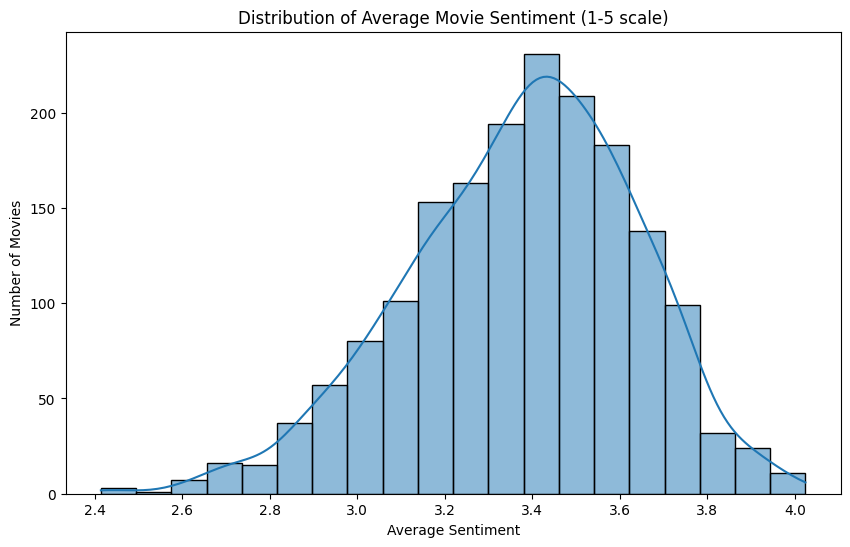

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(movie_summary['avg_sentiment'].dropna(), bins=20, kde=True)
plt.title('Distribution of Average Movie Sentiment (1-5 scale)')
plt.xlabel('Average Sentiment')
plt.ylabel('Number of Movies')
plt.show()

In [6]:
# Save the final movie summary dataset
out_path = os.path.join(DRIVE_BASE_DIR, 'movie_sentiment_summary.parquet')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
movie_summary.to_parquet(out_path, index=False)
print(f"Saved movie sentiment summary for {len(movie_summary)} movies.")

Saved movie sentiment summary for 1754 movies.
